In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
df = pd.read_csv(r"C:\Users\HP\Downloads\covid19.csv")

In [9]:
df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio
0,NaN,NaN,NaN,Afghanistan,2021-01-02 05:22:33,33.93911,67.709953,52513,2201,41727,8585,Afghanistan,134.896578,4.191343
1,NaN,NaN,NaN,Albania,2021-01-02 05:22:33,41.15330,20.168300,58316,1181,33634,23501,Albania,2026.409062,2.025173
2,NaN,NaN,NaN,Algeria,2021-01-02 05:22:33,28.03390,1.659600,99897,2762,67395,29740,Algeria,227.809861,2.764848
3,NaN,NaN,NaN,Andorra,2021-01-02 05:22:33,42.50630,1.521800,8117,84,7463,570,Andorra,10505.403482,1.034865
4,NaN,NaN,NaN,Angola,2021-01-02 05:22:33,-11.20270,17.873900,17568,405,11146,6017,Angola,53.452981,2.305328


In [10]:
df.shape

(4011, 14)

In [8]:
df.columns

Index(['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update',
       'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FIPS                 3265 non-null   float64
 1   Admin2               3270 non-null   str    
 2   Province_State       3833 non-null   str    
 3   Country_Region       4011 non-null   str    
 4   Last_Update          4011 non-null   str    
 5   Lat                  3922 non-null   float64
 6   Long_                3922 non-null   float64
 7   Confirmed            4011 non-null   int64  
 8   Deaths               4011 non-null   int64  
 9   Recovered            4011 non-null   int64  
 10  Active               4011 non-null   int64  
 11  Combined_Key         4011 non-null   str    
 12  Incident_Rate        3922 non-null   float64
 13  Case_Fatality_Ratio  3963 non-null   float64
dtypes: float64(5), int64(4), str(5)
memory usage: 660.4 KB


In [10]:
df.isnull().sum()

FIPS                   746
Admin2                 741
Province_State         178
Country_Region           0
Last_Update              0
Lat                     89
Long_                   89
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
Combined_Key             0
Incident_Rate           89
Case_Fatality_Ratio     48
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.describe()

,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Incident_Rate,Case_Fatality_Ratio
count,4011,4011.000000,4011.000000,4.011000e+03,4011.000000,4.011000e+03,4.011000e+03,4011.000000,4011.000000
mean,2021-01-02 03:03:02.540513,35.816425,-71.459738,2.102613e+04,476.518823,1.180731e+04,9.259591e+03,5741.190967,2.220596
min,2020-08-04 02:27:56,-71.949900,-175.198200,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2021-01-02 05:22:33,33.291264,-96.314056,7.010000e+02,9.000000,0.000000e+00,5.780000e+02,3621.931930,0.977039
50%,2021-01-02 05:22:33,37.910342,-86.708116,1.968000e+03,31.000000,0.000000e+00,1.657000e+03,5840.344304,1.551567
75%,2021-01-02 05:22:33,42.036007,-77.622612,7.693500e+03,112.000000,0.000000e+00,4.915500e+03,7682.328668,2.324650
max,2021-04-02 15:13:53,71.706900,178.065000,2.636045e+06,81593.000000,2.114760e+06,2.400750e+06,27388.219766,1026.206897
std,NaN,13.245578,54.652417,1.055172e+05,2833.090464,8.193885e+04,5.719777e+04,3191.393132,17.071931


In [50]:
df["Last_Update"] = pd.to_datetime(df["Last_Update"])
df["Last_Update"].dtype

dtype('<M8[us]')

In [51]:
num_cols = ["Lat", "Long_", "Incident_Rate", "Case_Fatality_Ratio"]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [52]:
df.isnull().sum()

FIPS                   0
Admin2                 0
Province_State         0
Country_Region         0
Last_Update            0
Lat                    0
Long_                  0
Confirmed              0
Deaths                 0
Recovered              0
Active                 0
Combined_Key           0
Incident_Rate          0
Case_Fatality_Ratio    0
Date                   0
dtype: int64

In [53]:
text_cols = ["FIPS", "Admin2", "Province_State"]

df[text_cols] = df[text_cols].fillna("Unknown")

In [54]:
df.isnull().sum()

FIPS                   0
Admin2                 0
Province_State         0
Country_Region         0
Last_Update            0
Lat                    0
Long_                  0
Confirmed              0
Deaths                 0
Recovered              0
Active                 0
Combined_Key           0
Incident_Rate          0
Case_Fatality_Ratio    0
Date                   0
dtype: int64

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FIPS                 4011 non-null   object        
 1   Admin2               4011 non-null   str           
 2   Province_State       4011 non-null   str           
 3   Country_Region       4011 non-null   str           
 4   Last_Update          4011 non-null   datetime64[us]
 5   Lat                  4011 non-null   float64       
 6   Long_                4011 non-null   float64       
 7   Confirmed            4011 non-null   int64         
 8   Deaths               4011 non-null   int64         
 9   Recovered            4011 non-null   int64         
 10  Active               4011 non-null   int64         
 11  Combined_Key         4011 non-null   str           
 12  Incident_Rate        4011 non-null   float64       
 13  Case_Fatality_Ratio  4011 non-null   float64

In [56]:
df.head()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key,Incident_Rate,Case_Fatality_Ratio,Date
0,Unknown,Unknown,Unknown,Afghanistan,2021-01-02 05:22:33,33.93911,67.709953,52513,2201,41727,8585,Afghanistan,134.896578,4.191343,2021-01-02
1,Unknown,Unknown,Unknown,Albania,2021-01-02 05:22:33,41.15330,20.168300,58316,1181,33634,23501,Albania,2026.409062,2.025173,2021-01-02
2,Unknown,Unknown,Unknown,Algeria,2021-01-02 05:22:33,28.03390,1.659600,99897,2762,67395,29740,Algeria,227.809861,2.764848,2021-01-02
3,Unknown,Unknown,Unknown,Andorra,2021-01-02 05:22:33,42.50630,1.521800,8117,84,7463,570,Andorra,10505.403482,1.034865,2021-01-02
4,Unknown,Unknown,Unknown,Angola,2021-01-02 05:22:33,-11.20270,17.873900,17568,405,11146,6017,Angola,53.452981,2.305328,2021-01-02


In [57]:
total_confirmed = df["Confirmed"].sum()
print("Total Confirmed Cases:", total_confirmed)

Total Confirmed Cases: 84335814


In [58]:
total_deaths = df["Deaths"].sum()
print("Total Deaths:", total_deaths)

Total Deaths: 1911317


In [60]:
total_recovered = df["Recovered"].sum()
print("Total Recovered:", total_recovered)

Total Recovered: 47359111


In [61]:
total_active = df["Active"].sum()
print("Total Active Cases:", total_active)

Total Active Cases: 37140221


In [62]:
summary = pd.DataFrame({
    "Category": ["Confirmed", "Deaths", "Recovered", "Active"],
    "Total": [
        df["Confirmed"].sum(),
        df["Deaths"].sum(),
        df["Recovered"].sum(),
        df["Active"].sum()
    ]
})

summary

,Category,Total
0,Confirmed,84335814
1,Deaths,1911317
2,Recovered,47359111
3,Active,37140221


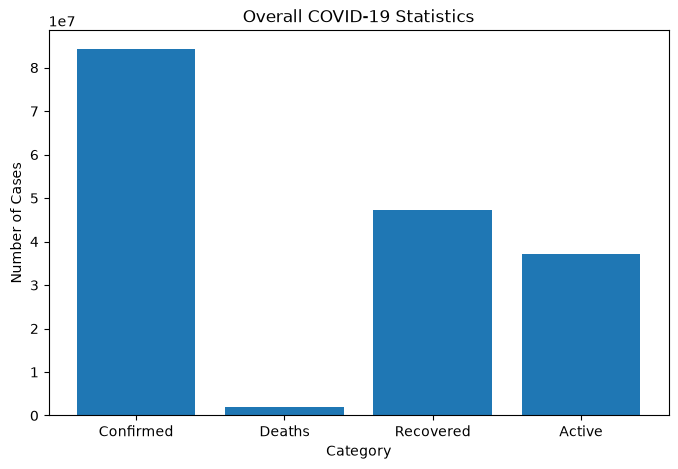

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(summary["Category"], summary["Total"])

plt.title("Overall COVID-19 Statistics")
plt.xlabel("Category")
plt.ylabel("Number of Cases")
plt.show()

In [64]:
average_fatality_rate = df["Case_Fatality_Ratio"].mean()

print("Average Case Fatality Ratio:", average_fatality_rate)

Average Case Fatality Ratio: 2.220595843864949


In [65]:
country_confirmed = df.groupby("Country_Region")["Confirmed"].sum().sort_values(ascending=False)

country_confirmed.head(10)

Country_Region
US                20397401
India             10305788
Brazil             7703971
Russia             3153960
France             2697014
United Kingdom     2549671
Turkey             2220855
Italy              2129376
Spain              1928265
Germany            1721839
Name: Confirmed, dtype: int64

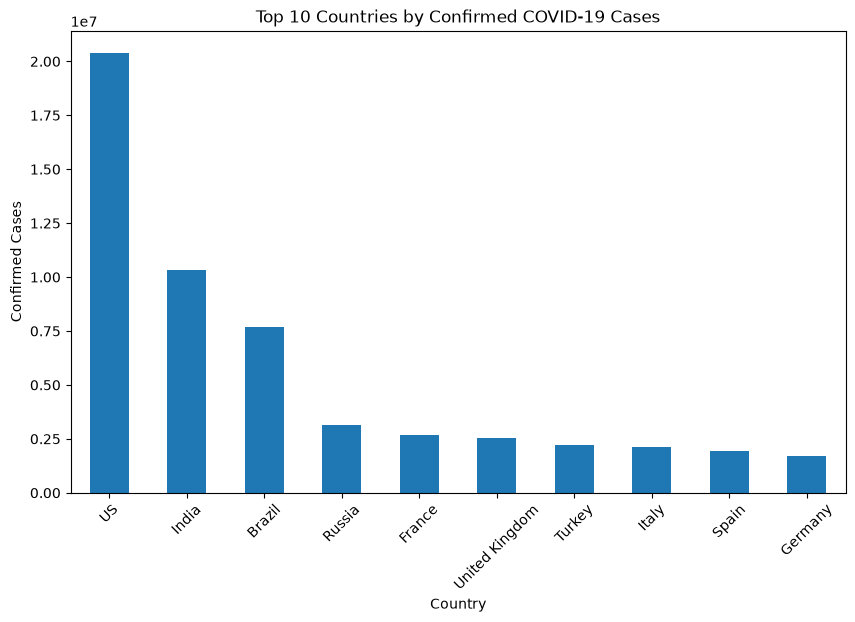

In [66]:
top10_confirmed = country_confirmed.head(10)

plt.figure(figsize=(10, 6))
top10_confirmed.plot(kind="bar")

plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

In [67]:
country_deaths = df.groupby("Country_Region")["Deaths"].sum().sort_values(ascending=False)

country_deaths.head(10)

Country_Region
US                352844
Brazil            195541
India             149218
Mexico            126507
United Kingdom     95917
Peru               93231
Italy              74621
France             64891
Russia             56798
Iran               55337
Name: Deaths, dtype: int64

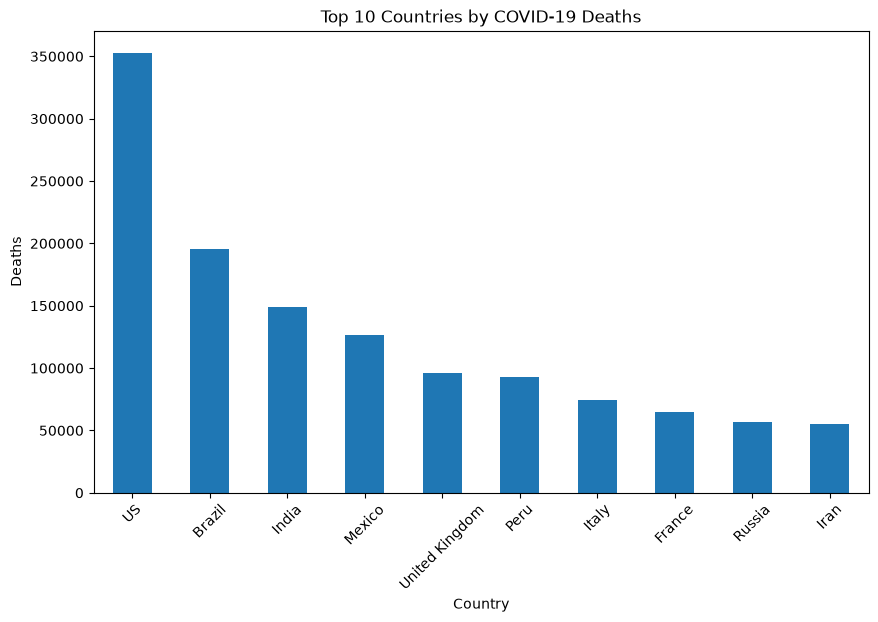

In [68]:
top10_deaths = country_deaths.head(10)

plt.figure(figsize=(10, 6))
top10_deaths.plot(kind="bar")

plt.title("Top 10 Countries by COVID-19 Deaths")
plt.xlabel("Country")
plt.ylabel("Deaths")
plt.xticks(rotation=45)
plt.show()

In [69]:
country_recovered = df.groupby("Country_Region")["Recovered"].sum().sort_values(ascending=False)

country_recovered.head(10)

Country_Region
India        9929568
Brazil       6855372
Russia       2553467
Turkey       2114760
Colombia     1520548
Italy        1479988
Argentina    1426676
Germany      1388744
Mexico       1083768
Poland       1046281
Name: Recovered, dtype: int64

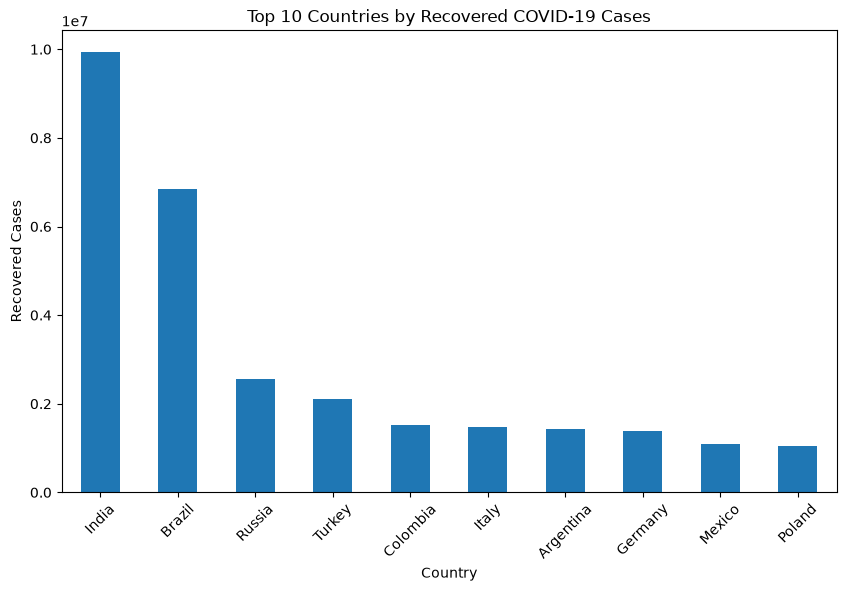

In [70]:
top10_recovered = country_recovered.head(10)

plt.figure(figsize=(10, 6))
top10_recovered.plot(kind="bar")

plt.title("Top 10 Countries by Recovered COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Recovered Cases")
plt.xticks(rotation=45)
plt.show()

In [71]:
country_analysis = df.groupby("Country_Region")[[
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active"
]].sum().sort_values("Confirmed", ascending=False)

country_analysis.head(10)

,Confirmed,Deaths,Recovered,Active
Country_Region,,,,
US,20397401,352844,0,19978335
India,10305788,149218,9929568,273109
Brazil,7703971,195541,6855372,649795
Russia,3153960,56798,2553467,543695
France,2697014,64891,200822,2431301
United Kingdom,2549671,95917,5682,2469774
Turkey,2220855,21093,2114760,85002
Italy,2129376,74621,1479988,574767
Spain,1928265,50837,150376,1727052
